# Day 4A — SHAP Explainability

**User Engagement Intelligence**

Goal: explain *why* the champion Logistic Regression model predicts churn for a user.

**SHAP in plain language:** start from the model's average prediction across users.
Each feature gets a SHAP value = how much that feature pushed *this* user's
prediction **up** (higher churn risk) or **down** (lower risk). The SHAP values
sum to (prediction − average), so the story always adds up.

## 1. Load model, feature names, and data

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from explain import rebuild_feature_matrix, explain_user

model = joblib.load(PROJECT_ROOT / "models" / "churn_model.joblib")
feature_names = joblib.load(PROJECT_ROOT / "models" / "feature_names.joblib")
df = pd.read_csv(PROJECT_ROOT / "data" / "users_with_clusters.csv")

print(f"Model: {type(model).__name__}")
print(f"Features ({len(feature_names)}): {feature_names}")
print(f"Users: {len(df):,}")
df.head()

Model: LogisticRegression
Features (15): ['age', 'sessions_last_30_days', 'avg_session_duration_minutes', 'content_views_last_30_days', 'likes_last_30_days', 'shares_last_30_days', 'days_since_last_login', 'notifications_clicked_last_30_days', 'cluster_name_At-Risk/Dormant', 'cluster_name_Casual Browsers', 'cluster_name_Power Users', 'cluster_name_Steady Engagers', 'device_type_Android', 'device_type_Web', 'device_type_iOS']
Users: 10,000


,user_id,age,device_type,sessions_last_30_days,avg_session_duration_minutes,content_views_last_30_days,likes_last_30_days,shares_last_30_days,days_since_last_login,notifications_clicked_last_30_days,churn,cluster,cluster_name
0,U00001,22,Android,24,11.0,67,11,2,20,11,0,2,Steady Engagers
1,U00002,55,iOS,29,13.4,111,27,2,9,10,0,2,Steady Engagers
2,U00003,49,iOS,23,10.2,62,12,0,25,7,0,1,Casual Browsers
3,U00004,39,Android,13,6.5,45,6,0,25,4,0,1,Casual Browsers
4,U00005,38,Android,14,11.2,36,2,0,29,8,0,1,Casual Browsers


## 2. Rebuild the Day-3 feature matrix

Same one-hot encoding and the **exact column order** saved in `feature_names.joblib`
(required so coefficients / SHAP line up with the right inputs).

In [2]:
X = rebuild_feature_matrix(df, feature_names)
assert list(X.columns) == list(feature_names), "Column order must match Day 3"

# Predicted churn probabilities for picking example users later
df = df.copy()
df["churn_proba"] = model.predict_proba(X)[:, 1]

print(f"Feature matrix: {X.shape}")
print(df["churn_proba"].describe().round(3))

Feature matrix: (10000, 15)
count    10000.000
mean         0.323
std          0.334
min          0.000
25%          0.014
50%          0.183
75%          0.627
max          0.992
Name: churn_proba, dtype: float64


## 3. Create a SHAP LinearExplainer

We use `shap.LinearExplainer` because the champion is **Logistic Regression** —
a linear model. LinearExplainer uses the coefficients directly and is fast/exact
for linear models.

- **TreeExplainer** is for tree ensembles (Random Forest, XGBoost) — not needed here.
- **KernelExplainer** is model-agnostic but slow (samples perturbations). Overkill
  when a specialized linear explainer exists.

In [3]:
# LinearExplainer: exact + fast for linear/logistic models (uses coef_ / intercept_)
# Background data X is the reference distribution for feature baselines.
# max_samples=len(X) keeps the full background (default would subsample to 100).
masker = shap.maskers.Independent(X.values, max_samples=len(X))
explainer = shap.LinearExplainer(model, masker)

print(type(explainer))

<class 'shap.explainers._linear.LinearExplainer'>


## 4. Compute SHAP values

LinearExplainer is fast enough for all 10,000 rows. (For slower explainers you'd
sample ~2000 rows — we keep the full set so Day 5 can look up any user.)

In [4]:
# Returns a shap.Explanation: .values = (n_users, n_features) SHAP matrix
shap_explanation = explainer(X)

shap_values = np.asarray(shap_explanation.values)
if shap_values.ndim == 3:
    # Some SHAP versions return (n, features, classes) for classifiers
    shap_values = shap_values[:, :, 1]

print(f"SHAP values shape: {shap_values.shape}")
print(f"(should be {len(df)} users x {len(feature_names)} features)")

SHAP values shape: (10000, 15)
(should be 10000 users x 15 features)


## 5. Global explainability — SHAP beeswarm (summary plot)

Each dot is one user. Color = feature value (red high / blue low).
Horizontal position = SHAP value (right = more churn risk).
Features are ranked by overall importance (mean |SHAP|).

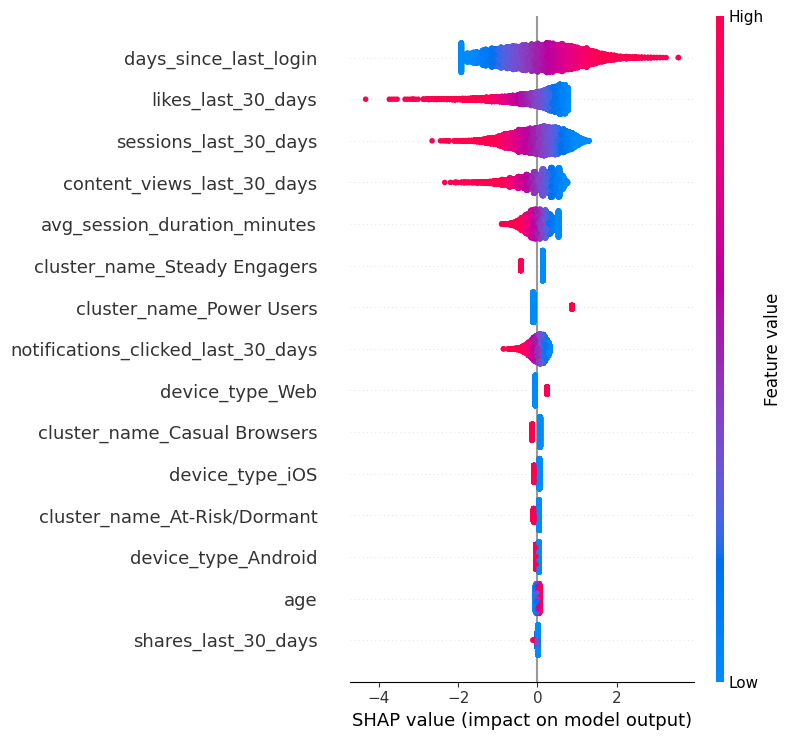

In [5]:
plt.figure()
# beeswarm = summary plot of SHAP values across all users
shap.summary_plot(
    shap_values,
    X,
    feature_names=feature_names,
    show=True,
    max_display=15,
)

In [6]:
# Mean |SHAP| = global importance ranking (easy interview talking point)
global_importance = (
    pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names)
    .sort_values(ascending=False)
)
print("Global feature importance (mean |SHAP|):")
print(global_importance.round(4))

Global feature importance (mean |SHAP|):
days_since_last_login                 0.8153
likes_last_30_days                    0.5362
sessions_last_30_days                 0.5002
content_views_last_30_days            0.3884
avg_session_duration_minutes          0.2225
cluster_name_Steady Engagers          0.2027
cluster_name_Power Users              0.1900
notifications_clicked_last_30_days    0.1484
device_type_Web                       0.0921
cluster_name_Casual Browsers          0.0910
device_type_iOS                       0.0612
cluster_name_At-Risk/Dormant          0.0579
device_type_Android                   0.0383
age                                   0.0257
shares_last_30_days                   0.0110
dtype: float64


## 6. Local explainability — three example users

Pick one **high-risk** (p > 0.8), one **medium-risk** (~0.4–0.6), and one **low-risk**
(p < 0.2). For each: waterfall plot + plain-English sentence via `explain_user()`.

In [7]:
def pick_example(mask, label):
    """Return one user_id matching the probability mask."""
    subset = df.loc[mask]
    if subset.empty:
        raise ValueError(f"No users found for {label}")
    # pick the median-probability user in the band for a stable demo
    idx = (subset["churn_proba"] - subset["churn_proba"].median()).abs().idxmin()
    return subset.loc[idx, "user_id"], subset.loc[idx, "churn_proba"]

high_id, high_p = pick_example(df["churn_proba"] > 0.8, "high-risk")
med_id, med_p = pick_example(
    (df["churn_proba"] >= 0.4) & (df["churn_proba"] <= 0.6), "medium-risk"
)
low_id, low_p = pick_example(df["churn_proba"] < 0.2, "low-risk")

examples = [
    ("High-risk", high_id, high_p),
    ("Medium-risk", med_id, med_p),
    ("Low-risk", low_id, low_p),
]
for label, uid, p in examples:
    print(f"{label:12s}  {uid}  churn_proba={p:.3f}")

High-risk     U06879  churn_proba=0.895
Medium-risk   U05653  churn_proba=0.495
Low-risk      U09343  churn_proba=0.015



========== High-risk: U06879 ==========
User U06879 has a 89% predicted churn probability. Main factors increasing risk: high days_since_last_login, low sessions_last_30_days, low likes_last_30_days. Main factors reducing risk: device_type_Android.

--- Waterfall: U06879 ---


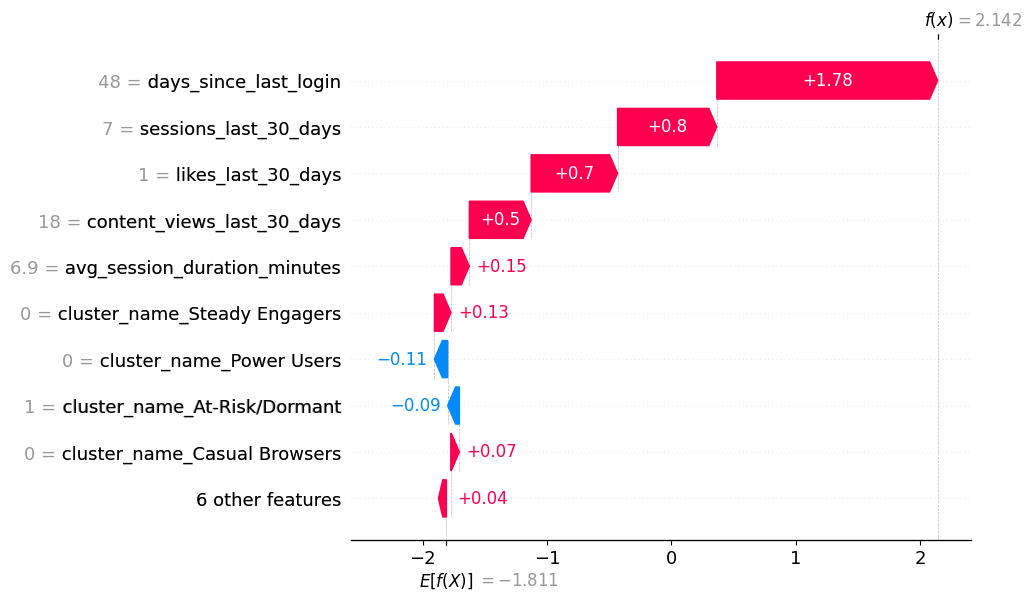


========== Medium-risk: U05653 ==========
User U05653 has a 50% predicted churn probability. Main factors increasing risk: low likes_last_30_days, high days_since_last_login, low sessions_last_30_days. Main factors reducing risk: low age.

--- Waterfall: U05653 ---


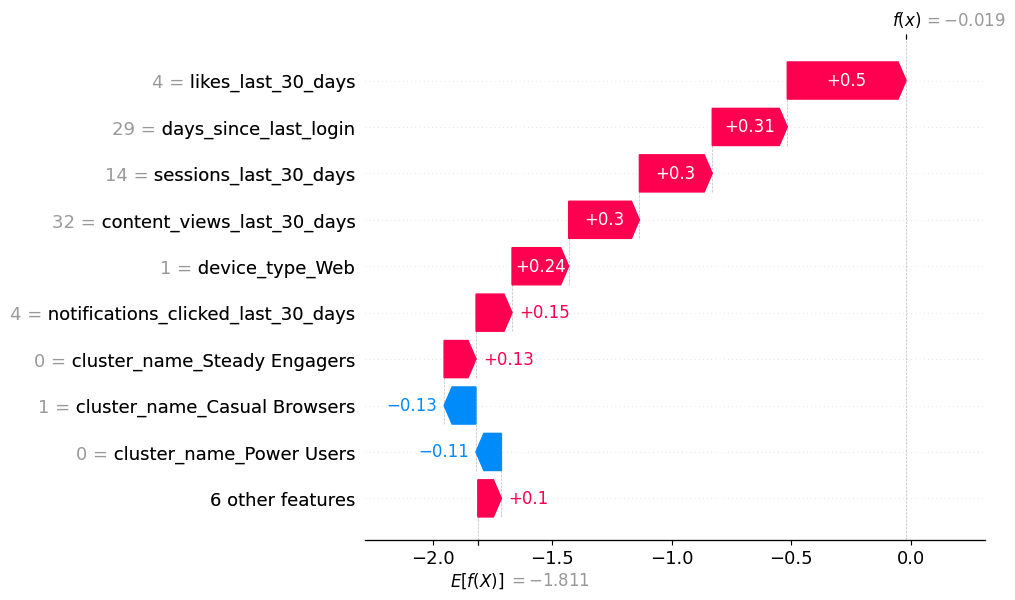


========== Low-risk: U09343 ==========
User U09343 has a 2% predicted churn probability. Main factors increasing risk: none notable. Main factors reducing risk: low days_since_last_login, high sessions_last_30_days, high likes_last_30_days.

--- Waterfall: U09343 ---


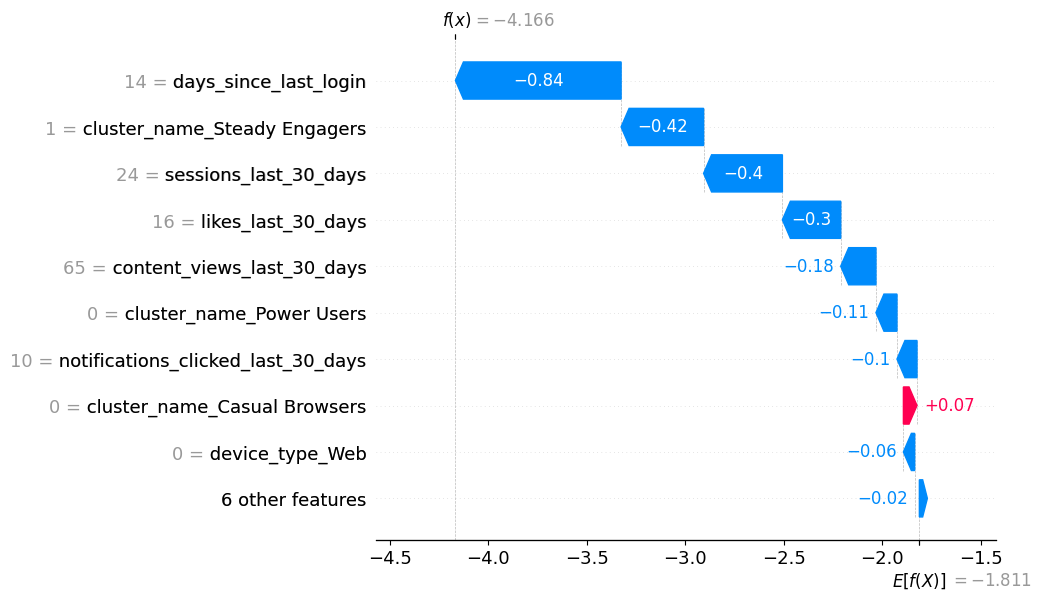

In [8]:
def waterfall_for_user(user_id):
    """Show a SHAP waterfall for one user (local explanation)."""
    # Position of this user in df / X / shap_explanation (same row order)
    pos = df.index[df["user_id"] == user_id][0]
    # iloc position if index is default RangeIndex
    iloc_pos = df.index.get_loc(pos)

    print(f"\n--- Waterfall: {user_id} ---")
    # waterfall: bars show how each feature moves prediction from E[f(X)] to f(x)
    shap.plots.waterfall(shap_explanation[iloc_pos], max_display=10, show=True)


for label, uid, _ in examples:
    print(f"\n========== {label}: {uid} ==========")
    explain_user(uid, df, model, explainer, feature_names)
    waterfall_for_user(uid)

## 7. Reusable `explain_user()` demo

Same function lives in `src/explain.py` for Day 5's Streamlit dashboard.

In [9]:
# Try any user_id from the dataset
explain_user("U00001", df, model, explainer, feature_names)
explain_user(high_id, df, model, explainer, feature_names)

User U00001 has a 3% predicted churn probability. Main factors increasing risk: high likes_last_30_days. Main factors reducing risk: high sessions_last_30_days, low days_since_last_login, high content_views_last_30_days.
User U06879 has a 89% predicted churn probability. Main factors increasing risk: high days_since_last_login, low sessions_last_30_days, low likes_last_30_days. Main factors reducing risk: device_type_Android.


'User U06879 has a 89% predicted churn probability. Main factors increasing risk: high days_since_last_login, low sessions_last_30_days, low likes_last_30_days. Main factors reducing risk: device_type_Android.'

## 8. Save explainer + SHAP values for Day 5

In [10]:
models_dir = PROJECT_ROOT / "models"
models_dir.mkdir(parents=True, exist_ok=True)

explainer_path = models_dir / "shap_explainer.joblib"
values_path = models_dir / "shap_values.joblib"

joblib.dump(explainer, explainer_path)
# Save values + user_id alignment so the dashboard can look up rows quickly
joblib.dump(
    {
        "user_ids": df["user_id"].tolist(),
        "feature_names": list(feature_names),
        "shap_values": shap_values,
        "churn_proba": df["churn_proba"].to_numpy(),
    },
    values_path,
)

print(f"Saved explainer   -> {explainer_path}")
print(f"Saved SHAP values -> {values_path}")

Saved explainer   -> D:\User Engagement Intelligence\models\shap_explainer.joblib
Saved SHAP values -> D:\User Engagement Intelligence\models\shap_values.joblib


## Day 4A summary

- Used **SHAP LinearExplainer** (right tool for Logistic Regression).
- **Global** beeswarm shows which features drive churn risk across the population.
- **Local** waterfalls + `explain_user()` turn a probability into a sentence a
  retention manager can act on.
- Artifacts: `models/shap_explainer.joblib`, `models/shap_values.joblib`.
- Next: Part B — rebuild engagement features from raw SQL event tables.